In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
prices = pd.read_csv("../data/raw/monthly_prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("../data/processed/monthly_returns.csv", index_col=0, parse_dates=True)
factors = pd.read_csv("../data/processed/ff_factors.csv", index_col=0, parse_dates=True)

print("价格数据:", prices.shape)
print("收益率数据:", returns.shape)
print("因子数据:", factors.shape)
print("\n时间范围:", returns.index[0].strftime("%Y-%m"), "→", returns.index[-1].strftime("%Y-%m"))

价格数据: (120, 50)
收益率数据: (119, 50)
因子数据: (119, 5)

时间范围: 2015-02 → 2024-12


In [2]:
# 收益率的描述性统计
desc = returns.describe().T  # 转置，让每只股票一行
desc = desc[["mean", "std", "min", "max"]]
desc.columns = ["月均收益", "月标准差", "最差月", "最好月"]

# 年化处理
desc["年化收益"] = desc["月均收益"] * 12
desc["年化波动率"] = desc["月标准差"] * np.sqrt(12)

# 按年化收益排序，看看哪些股票表现最好
print("表现最好的10只股票:")
print(desc.sort_values("年化收益", ascending=False).head(10)[["年化收益", "年化波动率", "最差月", "最好月"]].round(4))

print("\n表现最差的10只股票:")
print(desc.sort_values("年化收益", ascending=True).head(10)[["年化收益", "年化波动率", "最差月", "最好月"]].round(4))

表现最好的10只股票:
         年化收益   年化波动率     最差月     最好月
NVDA   0.6916  0.4670 -0.3202  0.3840
TSLA   0.5212  0.6247 -0.3673  0.7415
NFLX   0.3588  0.4141 -0.4918  0.4081
AMZN   0.3018  0.3068 -0.2375  0.2706
MSFT   0.2765  0.2136 -0.1074  0.1963
AAPL   0.2676  0.2761 -0.1840  0.2144
META   0.2658  0.3381 -0.3263  0.2716
FCX    0.2575  0.5866 -0.3690  0.6587
COST   0.2309  0.2037 -0.1535  0.1450
GOOGL  0.2268  0.2397 -0.1795  0.2175

表现最差的10只股票:
         年化收益   年化波动率     最差月     最好月
D      0.0240  0.1857 -0.1551  0.1245
SLB    0.0370  0.4132 -0.4947  0.4560
PFE    0.0532  0.2252 -0.1382  0.2284
VZ     0.0540  0.1840 -0.1070  0.1233
DIS    0.0701  0.2939 -0.1861  0.2487
JNJ    0.0777  0.1596 -0.1159  0.1442
DUK    0.0792  0.1764 -0.1219  0.1396
CMCSA  0.0857  0.2400 -0.1896  0.1954
T      0.0872  0.2057 -0.1723  0.1884
KO     0.0874  0.1627 -0.1727  0.1376


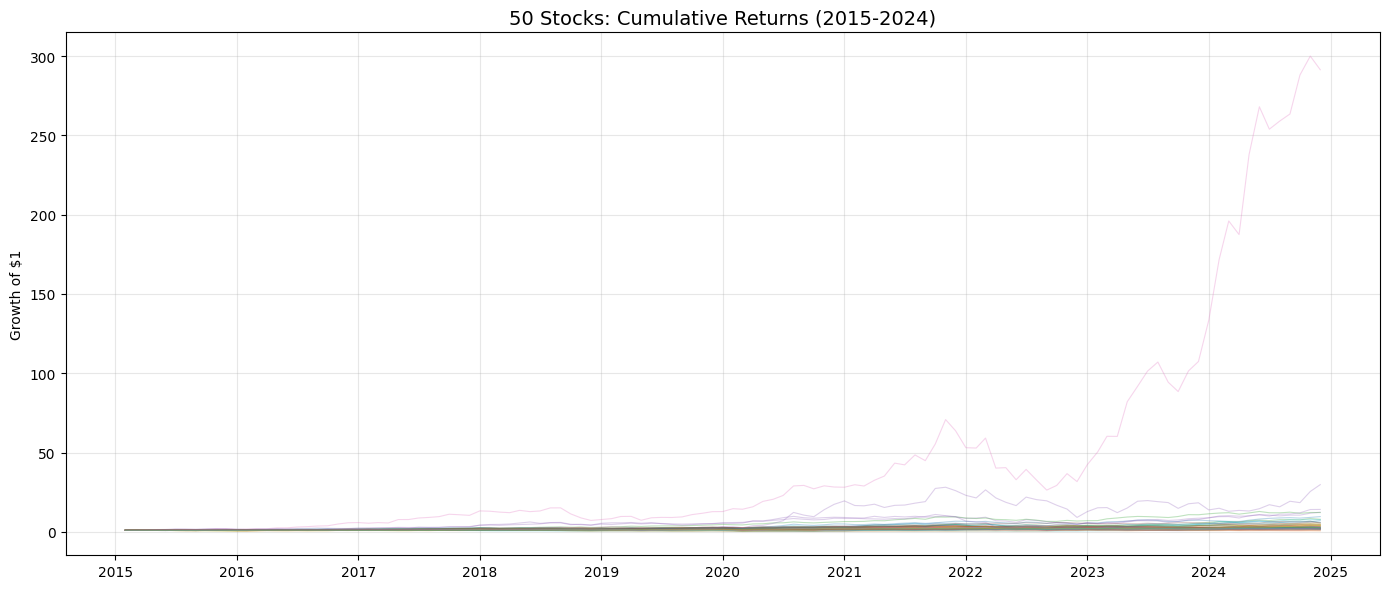

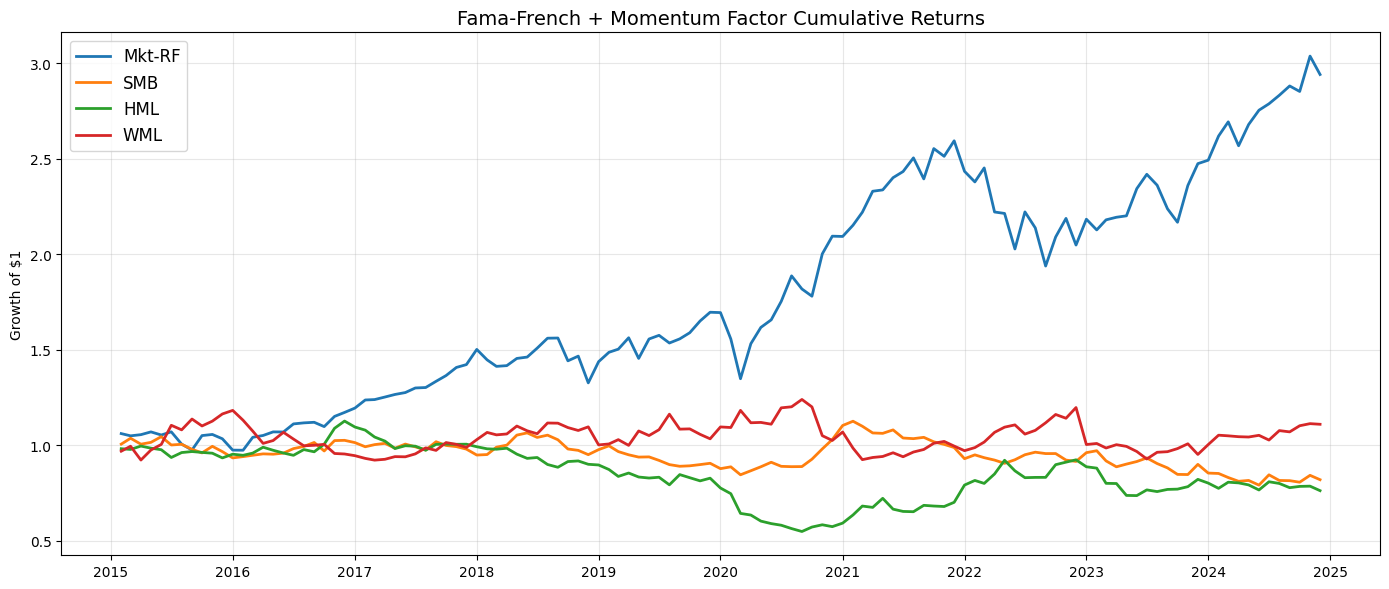

In [3]:
# 图1：所有股票的累计收益曲线
cumulative = (1 + returns).cumprod()

plt.figure(figsize=(14, 6))
for col in cumulative.columns:
    plt.plot(cumulative.index, cumulative[col], alpha=0.3, linewidth=0.8)
plt.title("50 Stocks: Cumulative Returns (2015-2024)", fontsize=14)
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 图2：四个因子的累计收益
factor_cols = ["Mkt-RF", "SMB", "HML", "WML"]
factor_cumulative = (1 + factors[factor_cols]).cumprod()

plt.figure(figsize=(14, 6))
for col in factor_cols:
    plt.plot(factor_cumulative.index, factor_cumulative[col], linewidth=2, label=col)
plt.title("Fama-French + Momentum Factor Cumulative Returns", fontsize=14)
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

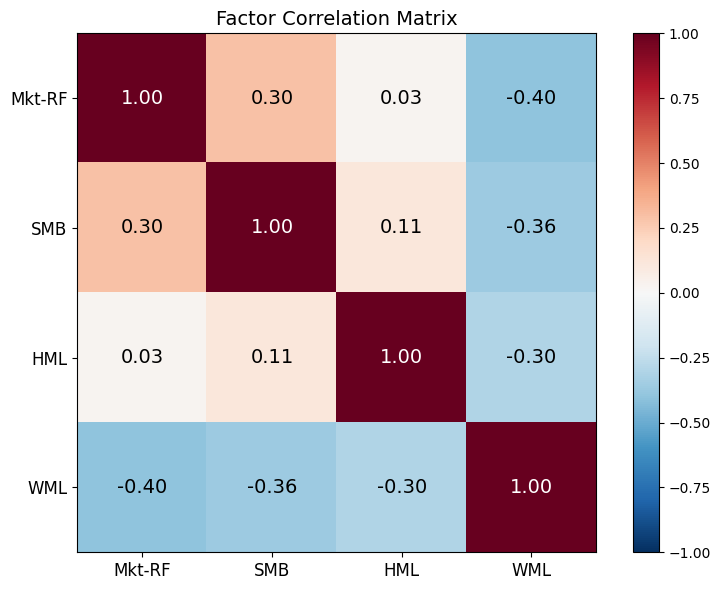

In [4]:
# 因子相关性矩阵
factor_corr = factors[["Mkt-RF", "SMB", "HML", "WML"]].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(factor_corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(4), ["Mkt-RF", "SMB", "HML", "WML"], fontsize=12)
plt.yticks(range(4), ["Mkt-RF", "SMB", "HML", "WML"], fontsize=12)
plt.colorbar(im)
plt.title("Factor Correlation Matrix", fontsize=14)

# 在格子里标数字
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{factor_corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=14,
                color="white" if abs(factor_corr.iloc[i, j]) > 0.5 else "black")

plt.tight_layout()
plt.show()